Model Hyparameters Config

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

# pai
seed = 42
model = 'llava-v1.5'
# model = 'minigpt4'
# model = "instructblip"
# model = "qwen-vl"
sample = False
temperature = -1
top_p = None
num_beams = 1
max_new_tokens = 512

#hyparams
use_jsd = 1
alpha = 0.6
beta = 0.6
threshold_top_p = 0.9
threshold_top_k = 20
early_exit_layers=[i for i in range(20, 26, 1)]

In [2]:
import argparse
import json
import random
import numpy as np
import torch
import torch.nn.functional as F
import torch.backends.cudnn as cudnn
from constants import INSTRUCTION_TEMPLATE, SYSTEM_MESSAGE
from eval_data_loader import COCODataSet
from llava.utils import disable_torch_init
from model_loader import ModelLoader
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from transformers import set_seed
from chair import CHAIR
import pickle

/home/zhr/.conda/envs/deco/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


load model

In [3]:
set_seed(seed)
disable_torch_init()

model_loader = ModelLoader(model)

Loading LLava


/home/zhr/.conda/envs/deco/lib/python3.9/site-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Loading checkpoint shards: 100%|██████████| 2/2 [01:00<00:00, 30.02s/it]


In [5]:
tokenizer = model_loader.tokenizer
# image_id = 226988
# image_id = 46011
# image_id = 310196
# image_id = 406810
# image_id = 507187
image_id = 433554
image_path = "/data1/zhr/datasets/coco2014/val2014/" + "COCO_val2014_"+str(image_id).zfill(12) + ".jpg"
image = Image.open(image_path).convert("RGB")

template = INSTRUCTION_TEMPLATE[model]

query = "Please help me describe the image in detail."
# query = "Is there a snowboard in the image?" # label:yes
# query = "Is there a car in the image?" # label:no
prefix = ""

prefix=" The image features a group of people gathered on a boat, enjoying a day of water sports. There are several individuals on the boat, with some of them wearing life jackets and holding onto ropes. A man is riding a "

# prefix = " The image showcases a spacious and well-decorated living room with a large couch and a coffee table. The couch is positioned in the center of the room, with a chair placed nearby. The coffee table is adorned with a "
# prefix = " Additionally, there are two "
# prefix = " A bench is visible in the background, and a "

if model == "llava-v1.5":
    model_loader.vlm_model.config.image_aspect_ratio = None

questions, kwargs = model_loader.prepare_inputs_for_model(template, query, image_path, prefix)

In [152]:
print(questions)

A chat between a curious human and an artificial intelligence assistant. The assistant gives helpful, detailed, and polite answers to the human's questions. USER: <image>
Please help me describe the image in detail. ASSISTANT:


In [9]:
# # baseline
# with torch.inference_mode():
#     outputs = model_loader.llm_model.generate(
#         do_sample=sample,
#         temperature=temperature,
#         top_p=top_p,
#         num_beams=num_beams,
#         max_new_tokens=max_new_tokens,
#         # min_new_tokens=60,
#         use_cache=True,
#         **kwargs,
#     )

# outputs = model_loader.decode(outputs)[0]

In [11]:
# use_jsd= 2
# alpha = 10
# beta = 0
# early_exit_layers=[i for i in range(20, 29, 1)]
# ci_min_val = 1000
# ci_min_alpha = -1
# min_alpha_list = []

# for alpha in tqdm(range(1,20)):
#     with torch.inference_mode():
#         output_dict, uncond_output_dict = model_loader.llm_model.generate(
#             do_sample=sample,
#             temperature=temperature,
#             top_p=top_p,
#             num_beams=num_beams,
#             max_new_tokens=512,
#             use_cache=True,
#             use_jsd=use_jsd,
#             alpha = alpha,
#             beta = beta,
#             threshold_top_p=threshold_top_p, 
#             threshold_top_k=threshold_top_k,
#             early_exit_layers=early_exit_layers,
#             return_dict=True,
#             return_dict_in_generate=True,
#             output_hidden_states=True,
#             output_scores=True,
#             **kwargs,
#         )

#     output_ids = output_dict.sequences
#     outputs = model_loader.decode(output_ids)[0]
#     evaluator = pickle.load(open("/data1/zhr/checkpoints/chair/cache.pkl", 'rb'))
#     cap_dict = evaluator.compute_sample_chair(outputs, image_id)
#     if cap_dict["metrics"]["CHAIRi"] < ci_min_val:
#         ci_min_val = cap_dict["metrics"]["CHAIRi"]
#         ci_min_alpha = alpha
#         min_alpha_list = [alpha]
#     elif cap_dict["metrics"]["CHAIRi"] == ci_min_val:
#         min_alpha_list.append(alpha)

# print("CHAIRi: ", ci_min_val, ci_min_alpha, min_alpha_list)


In [21]:
use_jsd= 2
# alpha = 37,4,87
alpha = 3
beta = 0
repetition_penalty = 1.2
early_exit_layers=[i for i in range(20, 29, 1)]


with torch.inference_mode():
    output_dict, uncond_output_dict = model_loader.llm_model.generate(
        do_sample=sample,
        temperature=temperature,
        # repetition_penalty=repetition_penalty,
        top_p=top_p,
        num_beams=num_beams,
        max_new_tokens=20,
        use_cache=True,
        use_jsd=use_jsd,
        alpha = alpha,
        beta = beta,
        threshold_top_p=threshold_top_p, 
        threshold_top_k=threshold_top_k,
        early_exit_layers=early_exit_layers,
        return_dict=True,
        return_dict_in_generate=True,
        output_hidden_states=True,
        output_scores=True,
        **kwargs,
    )

output_ids = output_dict.sequences
outputs = model_loader.decode(output_ids)[0]

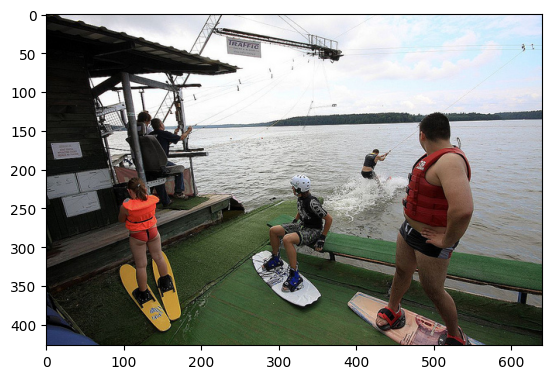

Ours:
 surfboard while others watch him closely. 

There are two boats visible in the scene


In [22]:
plt.imshow(image)
plt.show()
print("Ours:\n", outputs)

In [150]:
evaluator = pickle.load(open("/data1/zhr/checkpoints/chair/cache.pkl", 'rb'))
cap_dict = evaluator.compute_sample_chair(outputs, image_id)
print(cap_dict)

{'image_id': 84533, 'caption': 'The image features a woman riding a motorcycle parked outside a white building. She is sitting on the motorcycle, smiling and posing for the camera. The woman appears to be wearing leather attire, which complements her motorcycle riding style.\n\nThe motorcycle occupies most of the scene, with its front wheel prominently visible on the left side of the image. The woman is positioned centrally, with her motorcycle taking up a large portion of the frame.', 'mscoco_hallucinated_words': [], 'mscoco_gt_words': ['person', 'motorcycle'], 'mscoco_generated_words': ['person', 'motorcycle', 'motorcycle', 'person', 'motorcycle', 'motorcycle', 'person', 'motorcycle'], 'hallucination_idxs': [], 'metrics': {'CHAIRs': 0, 'CHAIRi': 0.0, 'Recall': 1.0, 'Len': 84}}


In [73]:
output_ids = output_dict.sequences
if kwargs.get("input_ids", None) is not None:
    input_token_len = kwargs["input_ids"].shape[1]
else:
    input_token_len = 0

target_word = "motorcycle"
start_idx = 12
outputs_tokens = output_ids[0, input_token_len:]
# words = tokenizer.decode(outputs_tokens[start_idx:start_idx+50]).encode("unicode_escape").decode()
for idx, token in enumerate(outputs_tokens[start_idx:]):
    word = tokenizer.decode(token)
    if word == target_word[:len(word)] and len(word) > 0:
        print(start_idx+idx, word, tokenizer.decode(outputs_tokens[start_idx+idx:start_idx+idx+10]))
        break


22 motor motorcycle is the main focus of the scene,


In [8]:
token_idx = 0
# token_idx = 16
threshold_top_k = 10
layer_logits = []
uncond_layer_logits = []

hidden_states = output_dict.hidden_states[token_idx]
uncond_hidden_states = uncond_output_dict.hidden_states[token_idx]

if model == "qwen-vl":
    layer_norm = model_loader.llm_model.transformer.ln_f
else:
    layer_norm = model_loader.llm_model.model.norm

for layer_id in range(0, 33):
    if layer_id != 32:
        layer_output = layer_norm(hidden_states[layer_id])
        uncond_layer_output = layer_norm(uncond_hidden_states[layer_id])
    else:
        layer_output = hidden_states[layer_id].clone()
        uncond_layer_output = uncond_hidden_states[layer_id].clone()
    logits = model_loader.llm_model.lm_head(layer_output)[:,-1,:]
    uncond_logits = model_loader.llm_model.lm_head(uncond_layer_output)[:,-1,:]
    layer_logits.append(logits)
    uncond_layer_logits.append(uncond_logits)

stacked_layer_logits = torch.stack(layer_logits, dim=0) # shape: (num_layers, batch_size, vocab_size)
stacked_uncond_layer_logits = torch.stack(uncond_layer_logits, dim=0)

layer_softmax = F.softmax(stacked_layer_logits, dim=-1) # shape: (num_layers, batch_size, vocab_size)
uncond_layer_softmax = F.softmax(stacked_uncond_layer_logits, dim=-1)

layer_log_softmax = F.log_softmax(stacked_layer_logits, dim=-1)
uncond_layer_log_softmax =F.log_softmax(stacked_uncond_layer_logits, dim=-1)

final_layer_softmax = layer_softmax[-1, :, :]
final_layer_log_softmax = layer_log_softmax[-1, :, :]

In [9]:
probs = layer_softmax.squeeze()
uncond_probs = uncond_layer_softmax.squeeze()
# probs = layer_log_softmax.squeeze()
# uncond_probs = uncond_layer_log_softmax.squeeze()

candidate_tokens_probs, top_k_candidate_tokens_ids = torch.topk(probs[-1], dim=-1, k=threshold_top_k)

candidate_tokens_cumulative_probs = candidate_tokens_probs.cumsum(dim=-1).float()
candidate_tokens_indices = torch.searchsorted(candidate_tokens_cumulative_probs, threshold_top_p, right=False)
candidate_tokens_cutoff_idx = torch.min(candidate_tokens_indices + 1, torch.tensor(threshold_top_k))   

candidate_tokens_ids = top_k_candidate_tokens_ids[:candidate_tokens_cutoff_idx]

candidate_tokens_early_exit_probs = probs[:,candidate_tokens_ids]
uncond_candidate_tokens_early_exit_probs = uncond_probs[:,candidate_tokens_ids]

top_k_words = [tokenizer.decode(t.cpu()) for t in top_k_candidate_tokens_ids]
top_p_words = [tokenizer.decode(t.cpu()) for t in candidate_tokens_ids]

final_softmax_score = F.softmax(output_dict.scores[token_idx][0], dim=-1)
final_tokens_probs, final_tokens_ids = torch.topk(final_softmax_score, dim=-1, k=threshold_top_k)

final_words = [tokenizer.decode(t.cpu()) for t in final_tokens_ids]

print("top_k_candidate_tokens\n", top_k_words)
print(candidate_tokens_probs)

print("top_p_candidate_tokens\n", top_p_words)
print(candidate_tokens_probs[:candidate_tokens_cutoff_idx])

# jsd 2
print("next token logits\n", output_dict.next_token_scores[token_idx][...,candidate_tokens_ids])
print("next token uncond logits\n", uncond_output_dict.scores[token_idx][...,candidate_tokens_ids])
print("target layer logits\n", output_dict.target_layer_scores[token_idx][...,candidate_tokens_ids])
print("uncond target layer logits\n", uncond_output_dict.target_layer_scores[token_idx][...,candidate_tokens_ids])
print("Target Layer idx: ", output_dict.target_layers[token_idx])
print("target layer max probs: ", output_dict.target_max_probs[token_idx])
print("uncond target layer max probs: ", uncond_output_dict.target_max_probs[token_idx])
print("final logits\n", output_dict.final_scores[token_idx][...,candidate_tokens_ids])


# jsd 4
# print("jsd_probs: ", output_dict.jsd_probs[token_idx])
# print("deco_probs: ", output_dict.deco_probs[token_idx])
# print("jsd_layer_idx: ", output_dict.jsd_layer_idx[token_idx])
# print("deco_layer_idx: ", output_dict.deco_layer_idx[token_idx])
# print("jsd_val: ", output_dict.jsd_val[token_idx])


print("final_tokens\n", final_words)
print(final_tokens_probs)

top_k_candidate_tokens
 ['jet', 'water', '3', 'w', 'k', '4', '2', 'sur', 'waters', 'bo']
tensor([0.3008, 0.1942, 0.0698, 0.0620, 0.0561, 0.0556, 0.0320, 0.0257, 0.0251,
        0.0189], device='cuda:0', dtype=torch.float16, grad_fn=<TopkBackward0>)
top_p_candidate_tokens
 ['jet', 'water', '3', 'w', 'k', '4', '2', 'sur', 'waters', 'bo']
tensor([0.3008, 0.1942, 0.0698, 0.0620, 0.0561, 0.0556, 0.0320, 0.0257, 0.0251,
        0.0189], device='cuda:0', dtype=torch.float16,
       grad_fn=<SliceBackward0>)
next token logits
 tensor([[17.3594, 16.9219, 15.8984, 15.7812, 15.6797, 15.6719, 15.1172, 14.8984,
         14.8750, 14.5938]], device='cuda:0')
next token uncond logits
 tensor([[16.3281, 13.4609, 17.5000, 13.1641, 11.5078, 17.3750, 15.5703, 11.5547,
         12.5078, 10.0859]], device='cuda:0')
target layer logits
 tensor([[12.7344,  9.5312,  1.6465,  4.1094,  7.1133,  2.1094,  2.1055, 14.6562,
         13.8203,  6.3398]], device='cuda:0', dtype=torch.float16)
uncond target layer logits

In [10]:
# cross layer JSD
M = 0.5 * (layer_softmax[...,candidate_tokens_ids] + uncond_layer_softmax[...,candidate_tokens_ids])

kl1 = F.kl_div(layer_log_softmax[...,candidate_tokens_ids], M, reduction='none').mean(-1) # shape: (num_layers, batch_size)
kl2 = F.kl_div(uncond_layer_log_softmax[...,candidate_tokens_ids], M, reduction='none').mean(-1)
js_divs = 0.5 * (kl1 + kl2)
cross_layer_js_divs = js_divs.mean(-1) # shape: (num_layers,)

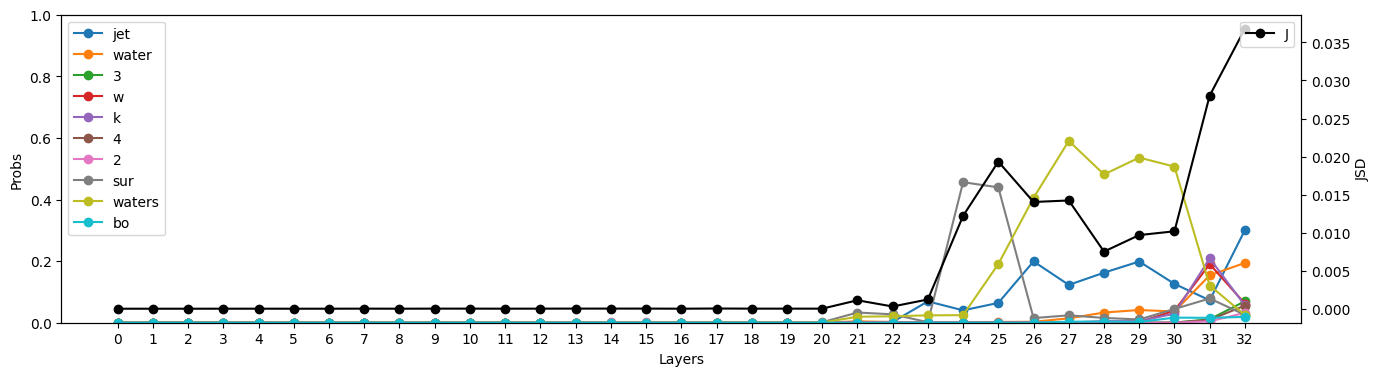

In [11]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(candidate_tokens_early_exit_probs.detach().cpu().numpy(), marker = 'o')
ax.set_xlabel("Layers")
ax.set_ylabel("Probs")
ax.set_xticks(range(33))
ax.set_ylim(0, 1)
ax.legend(top_p_words, loc='upper left')

# jsd = cross_layer_js_divs.max() - cross_layer_js_divs
jsd = cross_layer_js_divs

ax2 = ax.twinx()
ax2.plot(jsd.detach().cpu().numpy(), marker = 'o', color = 'black')
ax2.set_ylabel("JSD")
ax2.legend("J", loc='upper right')

plt.show()
# print("Max JS divergence idx: ", jsd.argmax().item())
# print("Target Layer idx: ", output_dict.target_layers[token_idx])

In [12]:
print(output_dict.target_layers[token_idx])
print(jsd[output_dict.target_layers[token_idx]])

25
tensor(0.0193, device='cuda:0', dtype=torch.float16, grad_fn=<SelectBackward0>)


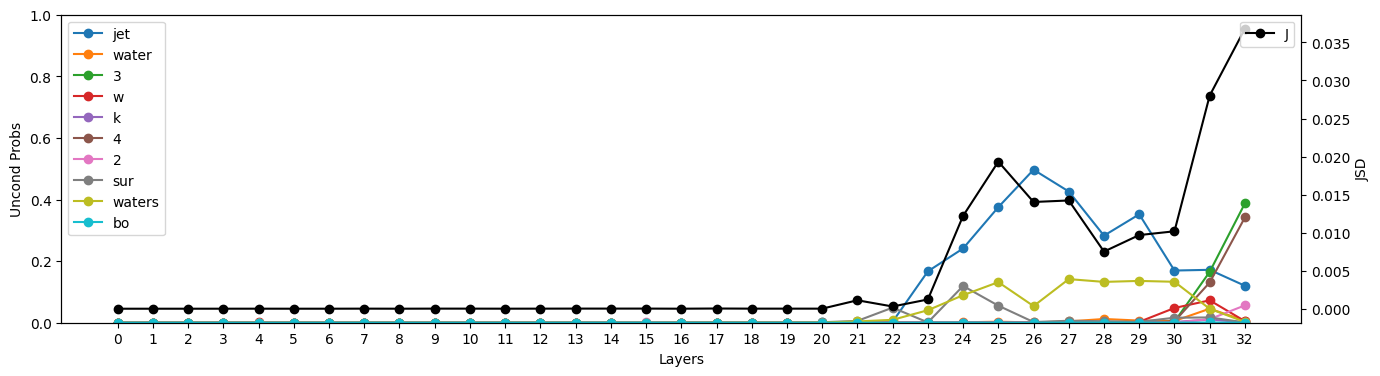

In [13]:
fig, ax = plt.subplots(figsize=(16, 4))

ax.plot(uncond_candidate_tokens_early_exit_probs.detach().cpu().numpy(), marker = 'o')
ax.set_xlabel("Layers")
ax.set_ylabel("Uncond Probs")
ax.set_xticks(range(33))
ax.set_ylim(0, 1)
ax.legend(top_p_words, loc='upper left')

# jsd = cross_layer_js_divs.max() - cross_layer_js_divs
jsd = cross_layer_js_divs

ax2 = ax.twinx()
ax2.plot(jsd.detach().cpu().numpy(), marker = 'o', color = 'black')
ax2.set_ylabel("JSD")
ax2.legend("J", loc='upper right')

plt.show()

In [14]:
fig_idx = [0,2,4]
# fig_idx = [0,1,2]
words = ['truck', 'motorcycle', 'bicycle']
# words = ['motorcycle', 'and', 'vehicle']

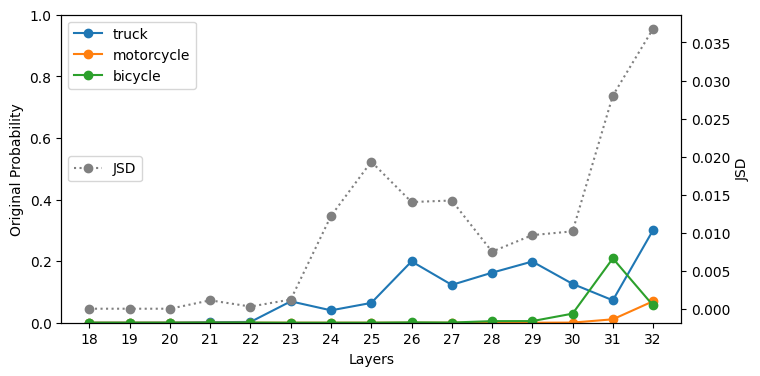

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(candidate_tokens_early_exit_probs.detach().cpu().numpy()[18:,fig_idx], marker = 'o')
ax.set_xlabel("Layers")
ax.set_ylabel("Original Probability")
ax.set_xticks(range(15), range(18,33))
ax.set_ylim(0, 1)
ax.legend(words, loc='upper left')

# jsd = cross_layer_js_divs.max() - cross_layer_js_divs
jsd = cross_layer_js_divs

ax2 = ax.twinx()
ax2.plot(jsd.detach().cpu().numpy()[18:], marker = 'o', color = 'gray', linestyle=':')
ax2.set_ylabel("JSD")
ax2.legend(["JSD"], loc='center left')

plt.savefig("6.jpg", dpi=500)
plt.show()

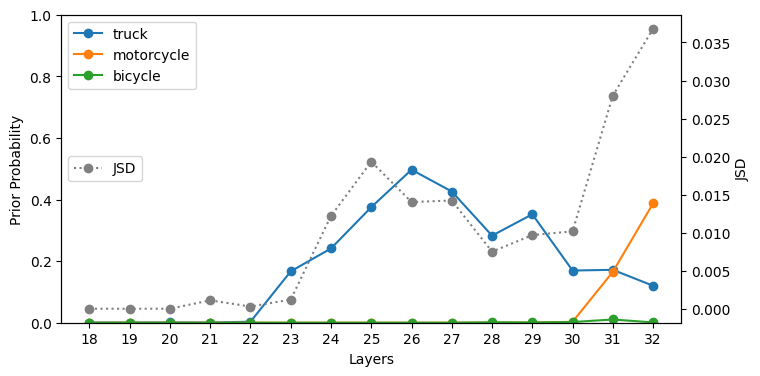

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(uncond_candidate_tokens_early_exit_probs.detach().cpu().numpy()[18:,fig_idx], marker = 'o')
ax.set_xlabel("Layers")
ax.set_ylabel("Prior Probability")
ax.set_xticks(range(15), range(18,33))
ax.set_ylim(0, 1)
ax.legend(words, loc='upper left')

# jsd = cross_layer_js_divs.max() - cross_layer_js_divs
jsd = cross_layer_js_divs

ax2 = ax.twinx()
ax2.plot(jsd.detach().cpu().numpy()[18:], marker = 'o', color = 'gray', linestyle=':')
ax2.set_ylabel("JSD")
ax2.legend(["JSD"], loc='center left')

plt.savefig("7.jpg", dpi=500)
plt.show()